In [16]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score
import pickle

In [7]:
# CARGO LOS DATOS
train = pd.read_csv("../data/processed/train_diabetes.csv")
test = pd.read_csv("../data/processed/test_diabetes.csv")

X_train = train.drop('Outcome', axis=1)
y_train = train['Outcome']

X_test = test.drop('Outcome', axis=1)
y_test = test['Outcome']

print("X_train.shape:", X_train.shape)
print("X_test.shape:", X_test.shape)

X_train.shape: (614, 8)
X_test.shape: (154, 8)


In [9]:
# ADABOOST
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.7792207792207793
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       100
           1       0.70      0.65      0.67        54

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.75       154
weighted avg       0.78      0.78      0.78       154



In [ ]:
# GRADIENT BOOSTING
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



**Analizar el impacto de n_estimators y learning_rate**

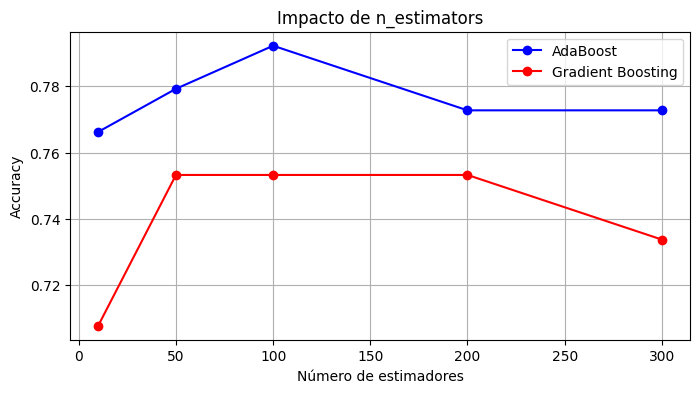

In [11]:
# Impacto de n_estimators
n_estimators = [10, 50, 100, 200, 300]
accuracy_ada = []
accuracy_gb = []

for n in n_estimators:
    model1 = AdaBoostClassifier(n_estimators=n, random_state=42)
    model1.fit(X_train, y_train)
    accuracy_ada.append(accuracy_score(y_test, model1.predict(X_test)))
    
    model2 = GradientBoostingClassifier(n_estimators=n, random_state=42)
    model2.fit(X_train, y_train)
    accuracy_gb.append(accuracy_score(y_test, model2.predict(X_test)))

# Graficar
plt.figure(figsize=(8, 4))
plt.plot(n_estimators, accuracy_ada, marker='o', label='AdaBoost', color='blue')
plt.plot(n_estimators, accuracy_gb, marker='o', label='Gradient Boosting', color='red')
plt.title('Impacto de n_estimators')
plt.xlabel('Número de estimadores')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout
plt.show()

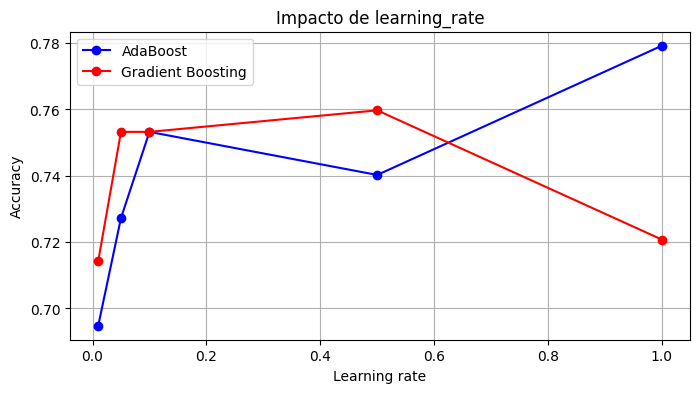

In [12]:
# Impacto de learning_rate
lr_values = [0.01, 0.05, 0.1, 0.5, 1.0]
lr_ada = []
lr_gb = []

for lr in lr_values:
    model1 = AdaBoostClassifier(learning_rate=lr, random_state=42)
    model1.fit(X_train, y_train)
    lr_ada.append(accuracy_score(y_test, model1.predict(X_test)))
    
    model2 = GradientBoostingClassifier(learning_rate=lr, random_state=42)
    model2.fit(X_train, y_train)
    lr_gb.append(accuracy_score(y_test, model2.predict(X_test)))

# Graficar
plt.figure(figsize=(8, 4))
plt.plot(lr_values, lr_ada, marker='o', label='AdaBoost', color='blue')
plt.plot(lr_values, lr_gb, marker='o', label='Gradient Boosting', color='red')
plt.title('Impacto de learning_rate')
plt.xlabel('Learning rate')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout
plt.show()

**Optimizar con GridSearchCV**

In [13]:
config_data = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.5]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=config_data,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_gb.fit(X_train, y_train)

print("Mejores parámetros:", grid_gb.best_params_)
print("Mejor accuracy CV:", grid_gb.best_score_)

mejor_boost = grid_gb.best_estimator_
y_pred_boost = mejor_boost.predict(X_test)

print("Accuracy en test:", accuracy_score(y_test, y_pred_boost))
print(classification_report(y_test, y_pred_boost))

Mejores parámetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Mejor accuracy CV: 0.7687991470078634
Accuracy en test: 0.7467532467532467
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



**Comparación de los resultados de los tres modelos**

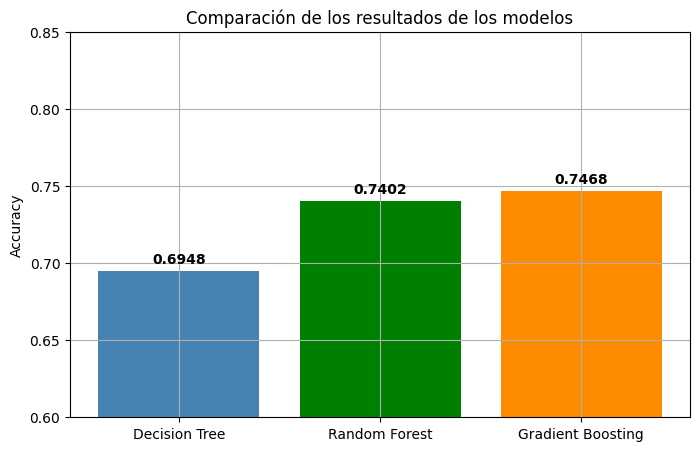

In [ ]:
# TABLA COMPARATIVA
modelos = {
    'Decision Tree': 0.6948,
    'Random Forest': 0.7402,
    'Gradient Boosting': accuracy_score(y_test, y_pred_boost)
}

# Gráfico de barras
colores = ['steelblue', 'green', 'darkorange']
plt.figure(figsize=(8, 5))
bars = plt.bar(modelos.keys(), modelos.values(), color=colores)
plt.title('Comparación de los resultados de los modelos')
plt.ylabel('Accuracy')
plt.ylim(0.60, 0.85)
for bar, val in zip(bars, modelos.values()):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.grid(True)
plt.tight_layout
plt.show()

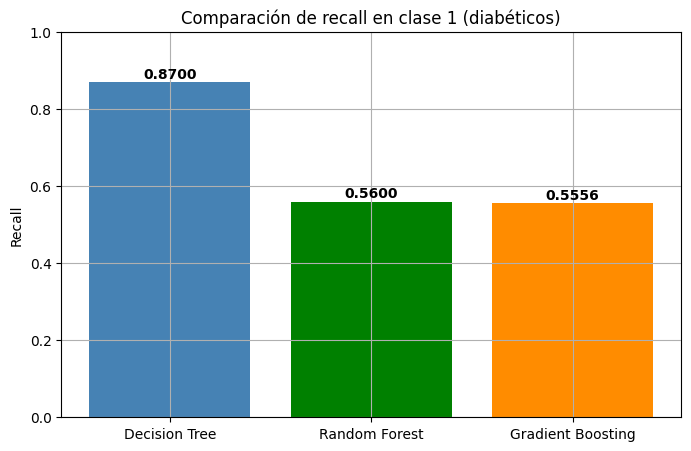

In [19]:
recalls = {
    'Decision Tree': 0.87,
    'Random Forest': 0.56,
    'Gradient Boosting': recall_score(y_test, y_pred_boost)
}

plt.figure(figsize=(8, 5))
bars = plt.bar(recalls.keys(), recalls.values(), color=colores)
plt.title('Comparación de recall en clase 1 (diabéticos)')
plt.ylabel('Recall')
plt.ylim(0, 1)
for bar, val in zip(bars, recalls.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.grid(True)
plt.tight_layout
plt.show()

NameError: name 'y_pred_dt' is not defined

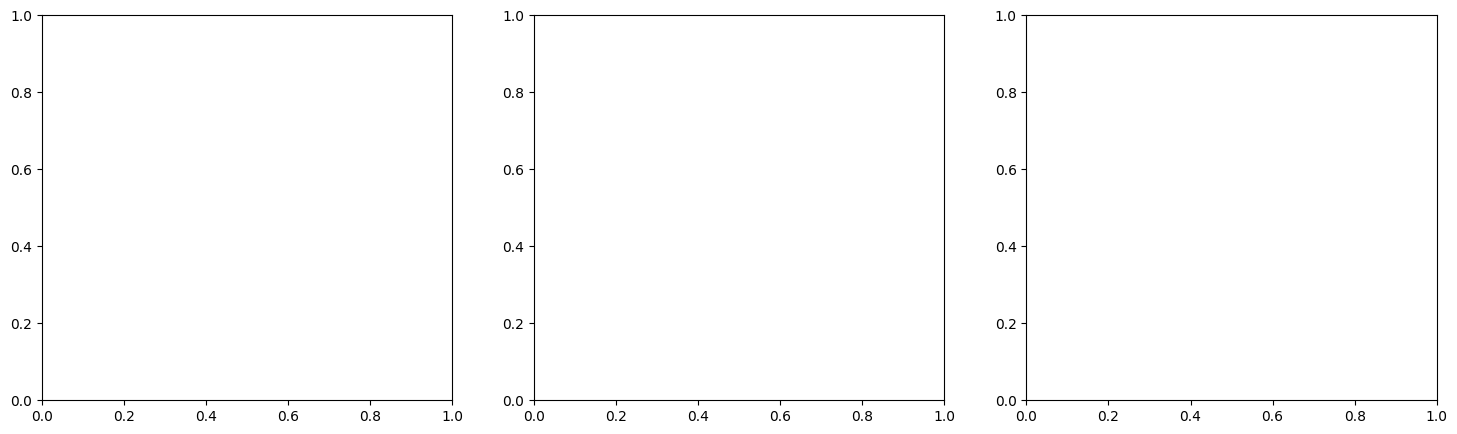

In [ ]:
# MATRIZ DE CONFUSIÓN DE LOS TRES MODELOS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, y_pred) in zip(axes, {
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_boost
}.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No Diabetes', 'Diabetes'],
        cmap='Blues', ax=ax
    )
    ax.set_title(nombre)
plt.grid(True)
plt.tight_layout
plt.show()

**Guardar modelo**

In [21]:
import os
os.makedirs("../models", exist_ok=True)

with open("../models/gradient_boosting_diabetes.pkl", "wb") as f:
    pickle.dump(mejor_boost, f)

print("Modelo guardado")

Modelo guardado


**Conclusiones**